# Gaming Deal Predictor — Model Training & Evaluation v7
### Multi-Class Steam Discount Prediction with Machine Learning
---
> **Team:** Betül Özen, Ömer Talha Patoz, Muhammet Enes Selçuk
>
> **Problem:** Multi-class classification — will a Steam game receive no discount (<50%), a medium discount (50–75%), or a big discount (≥75%) in the next 90 days?

## 📦 Section 1 — Setup & Data Loading

> **What we do here:** Import all required libraries, load the v7 Steam model dataset, and confirm everything looks right before modelling.

We use a **Steam Game Discount** dataset built from scratch using three live APIs — no pre-existing dataset was used. The dataset covers **{df['appid'].nunique()} unique games** across **{WINDOW_DAYS}-day windows** ({len(df)} samples). The target variable `label`:

- **0** = no or small discount (<50%)
- **1** = medium discount (50–75%)
- **2** = big discount (75–100%)

**Why these thresholds?** Three meaningful consumer tiers: small discounts barely worth waiting for, medium discounts worth considering, large discounts clearly worth waiting for.

| Feature | Type | Description |
|---|---|---|
| `game_age_days` | Continuous | Days since Steam release date at window start |
| `days_since_last_discount` | Continuous | Days since most recent recorded discount (≥10%). Capped at 365 days (domain-aware: 4 Steam sale seasons). |
| `n_itad_records` | Discrete | ITAD records in previous 90-day window |
| `max_discount_prev` | Continuous | Maximum discount % in previous 90-day window |
| `avg_discount_depth_prev` | Continuous | Average discount depth in previous 90-day window |
| `n_big_discounts_prev` | Discrete | Number of ≥50% discounts in previous 90-day window |
| `avg_discount_frequency` | Continuous | Fraction of past windows with a recorded discount |
| `never_discounted` | Binary | 1 if the game has never received a ≥10% discount before this window, 0 otherwise |
| `label` | 3-class target | 0 = <50%, 1 = 50–75%, 2 = 75–100% |

In [1]:
# CELL 2 — Imports & global plot settings + Load dataset
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import time, copy, json
import joblib
from IPython.display import display, HTML
from sklearn.preprocessing import StandardScaler
from sklearn.impute        import SimpleImputer
from sklearn.linear_model  import LogisticRegression
from sklearn.ensemble      import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes   import GaussianNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_auc_score, ConfusionMatrixDisplay
)

BLUE, BLUE_D, BLUE_L = "#2563eb", "#1e3a8a", "#bfdbfe"
SLATE, GREEN, RED    = "#334155", "#16a34a", "#dc2626"
MODEL_COLORS = ["#1e3a8a","#1d4ed8","#2563eb","#3b82f6"]
plt.rcParams.update({
    "figure.facecolor":"white","axes.facecolor":"#f8fafc",
    "axes.spines.top":False,"axes.spines.right":False,
    "axes.labelsize":12,"axes.titlesize":13,"axes.titleweight":"bold",
    "axes.grid":True,"grid.color":"#e2e8f0","grid.linewidth":0.6,
    "legend.frameon":False,
})
SEED = 42

# ── Load v7 metadata ──────────────────────────────────────────────
with open("model_meta_v7.json") as f:
    meta = json.load(f)

FEATURES    = meta["features"]
CLASS_NAMES = meta["class_names"]
WINDOW_DAYS = meta["window_days"]
N_GAMES     = 4000
TARGET      = "label"

# ── Load datasets from CSV ────────────────────────────────────────
train_df = pd.read_csv("train_v7.csv")
test_df  = pd.read_csv("test_v7.csv")
df       = pd.concat([train_df, test_df], ignore_index=True)

# ── Load imputer & scaler ─────────────────────────────────────────
imp    = joblib.load("imputer_v7.joblib")
scaler = joblib.load("scaler_v7.joblib")

# ── Rebuild scaled train/test matrices ───────────────────────────
X_train_sc = pd.DataFrame(
    scaler.transform(imp.transform(train_df[FEATURES])),
    columns=FEATURES, index=train_df.index)
X_test_sc  = pd.DataFrame(
    scaler.transform(imp.transform(test_df[FEATURES])),
    columns=FEATURES, index=test_df.index)
y_train = train_df[TARGET].values
y_test  = test_df[TARGET].values

# ── Load all trained models ───────────────────────────────────────
trained = {}
for name in meta["model_names"]:
    fname = f"model_v7_{name.lower().replace(' ', '_')}.joblib"
    trained[name] = joblib.load(fname)
    print(f"Loaded: {name}")

best_model_name = meta["best_model_name"]
best_model      = trained[best_model_name]

print(f"\nDataset shape      : {df.shape}")
print(f"Unique games       : {df['appid'].nunique()}")
print(f"Window days        : {WINDOW_DAYS}")
print(f"Features           : {FEATURES}")
print(f"Class names        : {CLASS_NAMES}")
print(f"Best model         : {best_model_name}")
print(f"\nClass distribution:")
for i, name in enumerate(CLASS_NAMES):
    cnt = (df[TARGET]==i).sum()
    print(f"  Class {i} ({name}): {cnt} ({cnt/len(df)*100:.1f}%)")

Loaded: Logistic Regression
Loaded: Random Forest
Loaded: Gradient Boosting
Loaded: Naive Bayes

Dataset shape      : (4377, 15)
Unique games       : 2214
Window days        : 90
Features           : ['game_age_days', 'days_since_last_discount', 'n_itad_records', 'max_discount_prev', 'avg_discount_depth_prev', 'n_big_discounts_prev', 'avg_discount_frequency', 'never_discounted']
Class names        : ['No/Small (<50%)', 'Medium (50–75%)', 'Big (75–100%)']
Best model         : Random Forest

Class distribution:
  Class 0 (No/Small (<50%)): 1135 (25.9%)
  Class 1 (Medium (50–75%)): 1470 (33.6%)
  Class 2 (Big (75–100%)): 1772 (40.5%)


## ✂️ Section 2 — Preprocessing & Combined Split

> **v7 methodology:** We use a **combined split** — temporal ordering + game-based filter.
> Train set contains only **past windows** from games that do not appear in the test set.
> Test set contains only **future windows** from unseen games.
> This mirrors real deployment: the model learns from the past and predicts for future games it has never seen.

| | Games | Windows |
|---|---|---|
| Train | 1,760 | 3,481 |
| Test  | 454   | 896 |

> 💡 **Why combined?** Pure walk-forward (v5) lets the model see the same game in train and test. Pure game-based (v6 initial) had no temporal ordering. V7 combined split tests both dimensions simultaneously — and unlike v6, the train set is now restricted to the pre-cutoff period only, so the model cannot see future discount patterns during training.

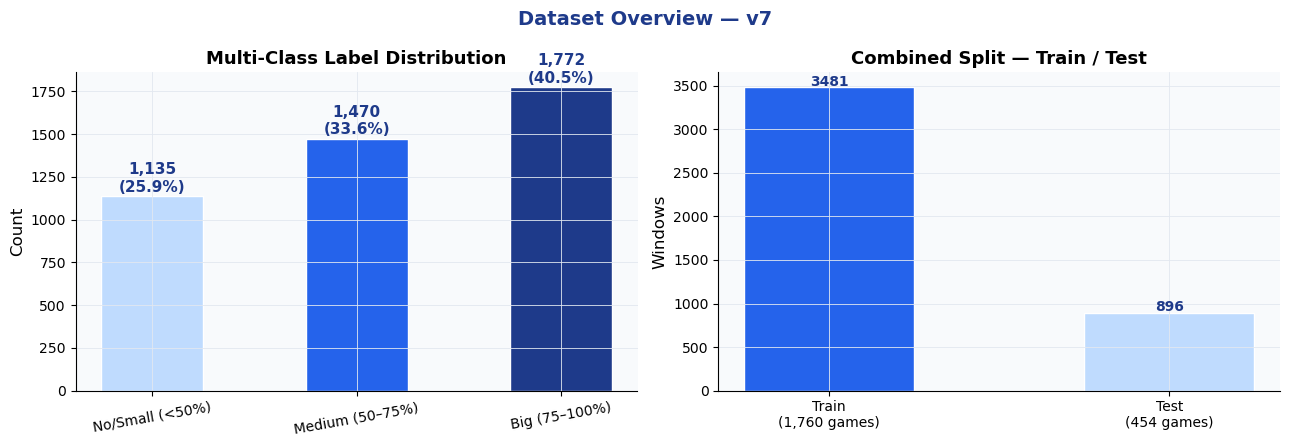

Train games : 1,760
Test games  : 454
Total games : 2,214


In [7]:
# CELL 3 — Class distribution & train/test overview
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle("Dataset Overview — v7", fontsize=14, fontweight="bold", color=BLUE_D)

colors = [BLUE_L, BLUE, BLUE_D]
counts = [len(df[df[TARGET]==i]) for i in range(len(CLASS_NAMES))]
bars   = axes[0].bar(CLASS_NAMES, counts, color=colors, edgecolor="white", width=0.5)
for bar, val in zip(bars, counts):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+10,
                 f"{val:,}\n({val/len(df):.1%})",
                 ha="center", va="bottom", fontsize=11, fontweight="bold", color=BLUE_D)
axes[0].set_ylabel("Count")
axes[0].set_title("Multi-Class Label Distribution")
axes[0].tick_params(axis='x', rotation=10)

split_counts = [len(train_df), len(test_df)]
split_labels = [f"Train\n({train_df['appid'].nunique():,} games)",
                f"Test\n({test_df['appid'].nunique():,} games)"]
axes[1].bar(split_labels, split_counts, color=[BLUE, BLUE_L], edgecolor="white", width=0.5)
for i, val in enumerate(split_counts):
    axes[1].text(i, val+20, str(val), ha="center", fontweight="bold", color=BLUE_D)
axes[1].set_ylabel("Windows")
axes[1].set_title("Combined Split — Train / Test")
plt.tight_layout()
plt.show()

print(f"Train games : {train_df['appid'].nunique():,}")
print(f"Test games  : {test_df['appid'].nunique():,}")
print(f"Total games : {df['appid'].nunique():,}")

In [9]:
# CELL 4 — Combined Split Visualisation
display(HTML(f"""
<div style="font-family:'Inter',sans-serif; margin:1.5rem 0;">
  <h3 style="color:#1e3a8a; margin-bottom:1.2rem;">🎮 Combined Split — Temporal + Game-Based</h3>
  <div style="display:grid; gap:.75rem;">
    <div style="display:flex; align-items:center; gap:.75rem;">
      <div style="width:80px; font-weight:600; color:#475569; font-size:.85rem;">Train</div>
      <div style="flex:4; background:#1e3a8a; border-radius:6px;
                  display:flex; align-items:center; justify-content:center;
                  color:white; font-size:.78rem; font-weight:600; height:38px;">
        {train_df['appid'].nunique():,} games — {len(train_df):,} windows — before cutoff
      </div>
    </div>
    <div style="display:flex; align-items:center; gap:.75rem;">
      <div style="width:80px; font-weight:600; color:#475569; font-size:.85rem;">Test</div>
      <div style="flex:1; background:#f97316; border-radius:6px;
                  display:flex; align-items:center; justify-content:center;
                  color:white; font-size:.78rem; font-weight:600; height:38px;">
        {test_df['appid'].nunique():,} games — {len(test_df):,} windows — after cutoff
      </div>
    </div>
  </div>
  <div style="margin-top:1rem; background:#eff6ff; border-left:4px solid #2563eb;
              border-radius:0 8px 8px 0; padding:.7rem 1rem; color:#1e3a8a; font-size:.85rem;">
    ✅ <strong>Same game never appears in both train and test.</strong>
    Train covers only pre-cutoff windows. Test covers only post-cutoff windows from unseen games.
    Imputer and scaler fit exclusively on training data.
    Window size: <strong>{WINDOW_DAYS} days</strong>.
  </div>
</div>
"""))

---
## 🤖 Section 3 — Model Training

> **What we do:** Train **four classifiers** on the combined split train set. All models predict three discount classes: No/Small (<50%), Medium (50–75%), Big (75–100%).

| Model | Type | Rationale |
|-------|------|----------|
| Logistic Regression | Linear | Interpretable baseline; log-odds coefficients show feature impact directly. Uses multinomial mode for multi-class. |
| Random Forest | Ensemble (bagging) | Reduces variance by averaging many trees. **v7: regularized with max_depth=15, min_samples_leaf=5 to reduce overfitting.** |
| Gradient Boosting | Ensemble (boosting) | Sequentially corrects errors; strongest performer on structured tabular data. |
| Naive Bayes | Probabilistic | Fast baseline. Assumes Gaussian class-conditional distributions — works well when features follow this pattern. |

Features were standardized before training. A fixed random seed (SEED = 42) was used for reproducibility. Missing values were imputed using median imputation fit exclusively on training data.

> ⚠️ **v7 change:** Models are evaluated on the combined split test set — test games were never seen during training, and test windows come from a later time period than training windows. This is the strictest evaluation in the project and produces the most realistic scores.

In [12]:
# CELL 5 — Load trained models
fit_times = {}

print(f"{'Model':<25} {'Load time':>10}")
print("-" * 38)
for name in meta["model_names"]:
    t0 = time.time()
    fname = f"model_v7_{name.lower().replace(' ', '_')}.joblib"
    trained[name] = joblib.load(fname)
    fit_times[name] = time.time() - t0
    print(f"  {name:<25} {fit_times[name]:.3f}s")

print(f"\nAll models loaded. Train set: {len(X_train_sc):,} windows from {train_df['appid'].nunique():,} games.")

Model                      Load time
--------------------------------------
  Logistic Regression       0.039s
  Random Forest             0.217s
  Gradient Boosting         0.043s
  Naive Bayes               0.000s

All models loaded. Train set: 3,481 windows from 1,760 games.


## 📊 Section 4 — Evaluation Metrics Explained

> Confusion matrix, accuracy, precision, F1 score, and AUC-ROC — all implemented here for multi-class prediction.

### The Confusion Matrix — Multi-Class

In v7 we have three classes. Each prediction falls into one of 9 cells (3×3 matrix):

| | **Pred: <50%** | **Pred: 50–75%** | **Pred: 75%+** |
|---|---|---|---|
| **Actual: <50%** | ✅ Correct | ❌ Under-estimated | ❌ Under-estimated |
| **Actual: 50–75%** | ❌ Over-estimated | ✅ Correct | ❌ Under-estimated |
| **Actual: 75%+** | ❌ Over-estimated | ❌ Over-estimated | ✅ Correct |

### Metrics — Weighted Averages

For multi-class problems, precision, recall and F1 are computed per class then averaged weighted by class size.

| Metric | What It Asks |
|---|---|
| Accuracy | What % of all predictions were correct? |
| Precision (weighted) | Of predicted discounts in each class, how many were correct? |
| Recall (weighted) | Of actual discounts in each class, how many did we catch? |
| F1 Score (weighted) | Harmonic mean of weighted precision & recall |
| AUC-ROC (OvR) | One-vs-Rest: how well does the model separate each class from the others? |

### Why errors matter in our problem

> 💡 **Most costly error:** Predicting <50% when the actual discount is 75%+ — the gamer buys at full price when a major sale is coming. 💸
>
> **Least costly error:** Predicting 75%+ when the actual discount is 50–75% — the gamer waits and still gets a decent discount.
>
> This is why **recall for the Big (75%+) class** is especially important, alongside overall **weighted F1** and **AUC-ROC**.

In [15]:
# CELL 6 — Compute all metrics
results = []
for name, model in trained.items():
    y_pred_tr = model.predict(X_train_sc)
    y_pred_te = model.predict(X_test_sc)
    y_prob_te = model.predict_proba(X_test_sc)
    try:
        auc = roc_auc_score(y_test, y_prob_te, multi_class='ovr', average='weighted')
    except:
        auc = None
    results.append({
        "Model"         : name,
        "Train Accuracy": accuracy_score(y_train, y_pred_tr),
        "Test Accuracy" : accuracy_score(y_test,  y_pred_te),
        "Precision (w)" : precision_score(y_test, y_pred_te, average='weighted', zero_division=0),
        "Recall (w)"    : recall_score(y_test, y_pred_te, average='weighted', zero_division=0),
        "F1 (w)"        : f1_score(y_test, y_pred_te, average='weighted', zero_division=0),
        "AUC (OvR)"     : round(auc, 4) if auc else None,
        "Load Time (s)" : fit_times[name],
    })

results_df = pd.DataFrame(results).set_index("Model")
display(results_df.style
    .format({"Train Accuracy":"{:.4f}", "Test Accuracy":"{:.4f}",
             "Precision (w)":"{:.4f}", "Recall (w)":"{:.4f}",
             "F1 (w)":"{:.4f}", "AUC (OvR)":"{:.4f}", "Load Time (s)":"{:.3f}"})
    .background_gradient(subset=["AUC (OvR)"], cmap="Blues", vmin=0.5, vmax=1.0)
    .background_gradient(subset=["F1 (w)"],    cmap="Blues", vmin=0.0, vmax=1.0)
    .highlight_max(subset=["Test Accuracy", "F1 (w)", "AUC (OvR)"], color="#bfdbfe")
    .set_caption(f"Evaluation Results — Combined Split Test Set ({len(y_test):,} windows, {test_df['appid'].nunique():,} games)"))

,Train Accuracy,Test Accuracy,Precision (w),Recall (w),F1 (w),AUC (OvR),Load Time (s)
Model,,,,,,,
Logistic Regression,0.7906,0.7969,0.8207,0.7969,0.7959,0.8880,0.039
Random Forest,0.8770,0.8225,0.8420,0.8225,0.8265,0.9434,0.217
Gradient Boosting,0.9041,0.7913,0.8213,0.7913,0.7979,0.9131,0.043
Naive Bayes,0.7693,0.7634,0.7675,0.7634,0.7639,0.8648,0.000


## 📈 Section 5 — Visual Model Comparison

> **Charts make the trade-offs immediately visible.** The bar charts below compare all 4 models on the metrics that matter most. All charts show results on the combined split test set

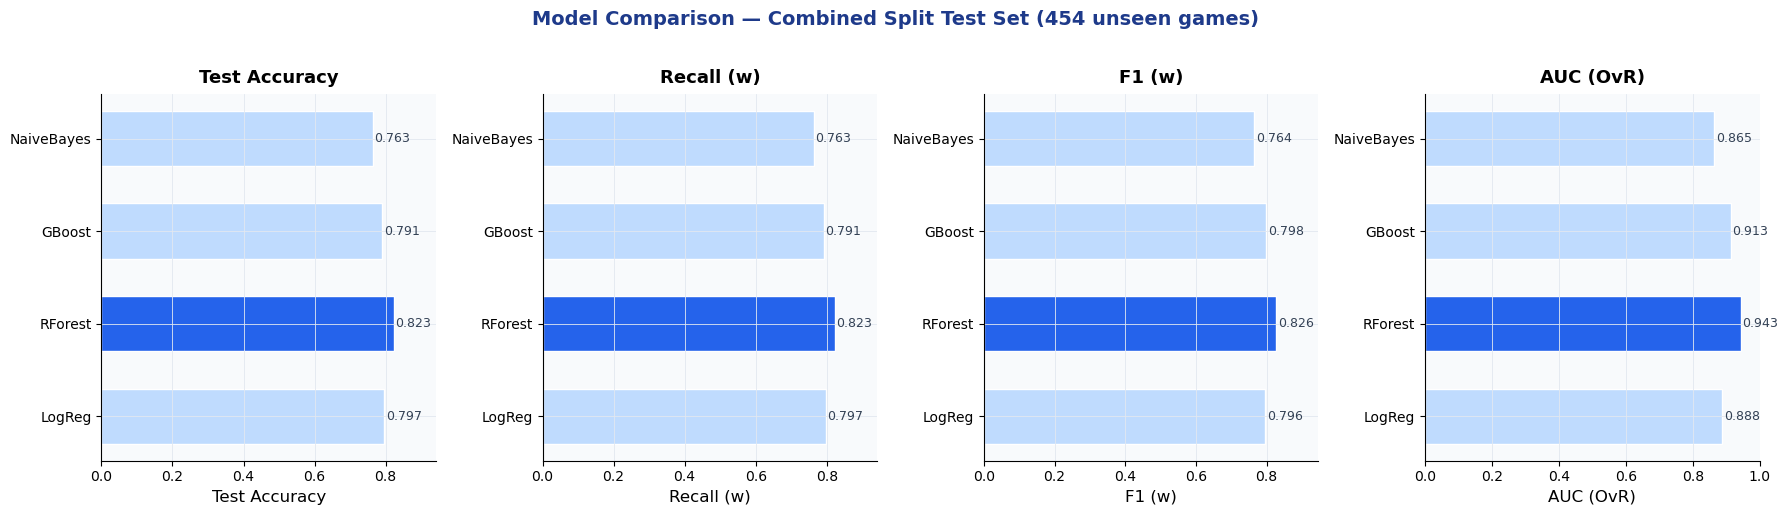

In [19]:
# CELL 7 — Bar chart comparison
model_names = results_df.index.tolist()
short_names = ["LogReg", "RForest", "GBoost", "NaiveBayes"]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle(f"Model Comparison — Combined Split Test Set ({test_df['appid'].nunique():,} unseen games)",
             fontsize=14, fontweight="bold", color=BLUE_D, y=1.02)

for ax, col in zip(axes, ["Test Accuracy", "Recall (w)", "F1 (w)", "AUC (OvR)"]):
    vals = results_df[col].values.astype(float)
    best = np.argmax(vals)
    cols = [BLUE if i==best else BLUE_L for i in range(len(vals))]
    ax.barh(short_names, vals, color=cols, edgecolor="white", height=0.6)
    ax.set_xlabel(col)
    ax.set_title(col, pad=8)
    ax.set_xlim(0, min(1.0, vals.max()+0.12))
    for i, val in enumerate(vals):
        ax.text(val+0.005, i, f"{val:.3f}", va="center", fontsize=9, color=SLATE)

plt.tight_layout()
plt.show()

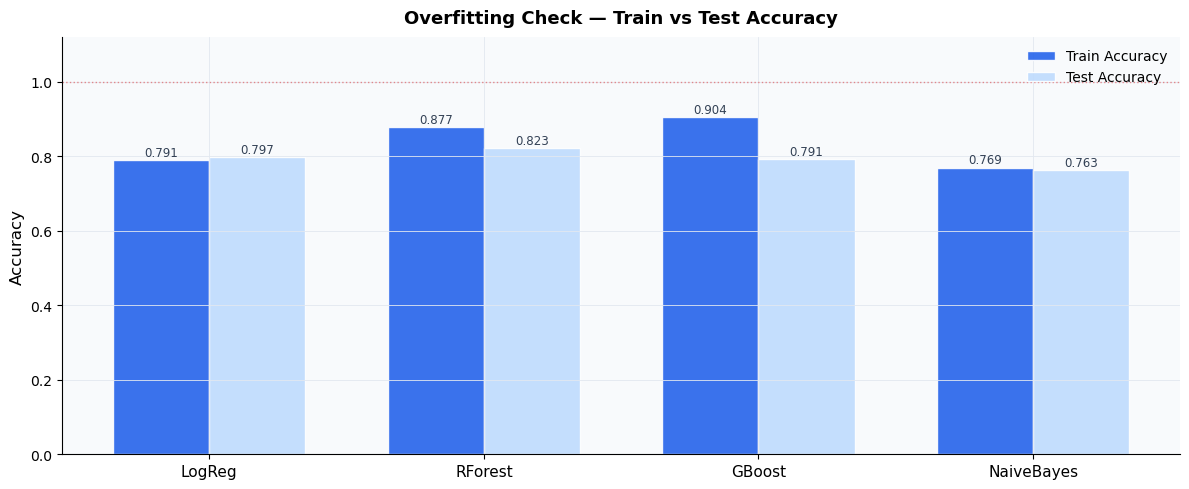


Overfitting analysis (Train - Test accuracy gap):
  LogReg         gap = -0.0063
  RForest        gap = +0.0545
  GBoost         gap = +0.1128  <-- POSSIBLE OVERFIT
  NaiveBayes     gap = +0.0059


In [21]:
# CELL 8 — Overfitting check
fig, ax = plt.subplots(figsize=(12, 5))
x_pos = np.arange(len(model_names))
width = 0.35

bars_tr = ax.bar(x_pos-width/2, results_df["Train Accuracy"], width,
                 label="Train Accuracy", color=BLUE, edgecolor="white", alpha=0.9)
bars_te = ax.bar(x_pos+width/2, results_df["Test Accuracy"], width,
                 label="Test Accuracy", color=BLUE_L, edgecolor="white", alpha=0.9)

for bar in list(bars_tr)+list(bars_te):
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h+0.003, f"{h:.3f}",
            ha="center", va="bottom", fontsize=8.5, color=SLATE)

ax.set_xticks(x_pos)
ax.set_xticklabels(short_names, fontsize=11)
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1.12)
ax.set_title("Overfitting Check — Train vs Test Accuracy", pad=10)
ax.legend()
ax.axhline(1.0, color="#dc2626", linewidth=1, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()

print("\nOverfitting analysis (Train - Test accuracy gap):")
for name, sname in zip(model_names, short_names):
    gap = results_df.loc[name, "Train Accuracy"] - results_df.loc[name, "Test Accuracy"]
    flag = "  <-- POSSIBLE OVERFIT" if gap > 0.08 else ""
    print(f"  {sname:<14} gap = {gap:+.4f}{flag}")

In [23]:
# CELL 8b — Interpretation notes
rf_gap = results_df.loc['Random Forest','Train Accuracy'] - results_df.loc['Random Forest','Test Accuracy']
best_te = results_df['Test Accuracy'].idxmax()
best_auc = results_df['AUC (OvR)'].idxmax()

display(HTML(f"""
<div style="font-family:'Inter',sans-serif; display:grid; gap:.75rem; margin-top:1.2rem;">
  <div style="background:#eff6ff; border-left:4px solid #2563eb;
              border-radius:0 8px 8px 0; padding:.9rem 1.2rem; color:#1e3a8a;">
    <strong>📌 Combined split evaluation.</strong> All charts show results on
    <strong>{test_df['appid'].nunique():,} games</strong> that were never seen during training,
    evaluated on windows from a later time period than training.
    This tests both temporal generalisation and unseen-game generalisation simultaneously.
  </div>
  <div style="background:#fefce8; border-left:4px solid #ca8a04;
              border-radius:0 8px 8px 0; padding:.9rem 1.2rem; color:#713f12;">
    <strong>💡 Interpreting the overfitting chart:</strong>
    <ul style="margin:.5rem 0 0 0; padding-left:1.2rem;">
      <li><strong>Random Forest</strong> leads on AUC
      ({results_df.loc['Random Forest','AUC (OvR)']:.3f}) and F1
      ({results_df.loc['Random Forest','F1 (w)']:.3f}).
      Train-test gap is {rf_gap:+.3f} — reduced from +0.133 in v6 thanks to
      max_depth=15 and min_samples_leaf=5 regularisation.</li>
      <li><strong>Gradient Boosting</strong> shows a small positive gap —
      train accuracy ({results_df.loc['Gradient Boosting','Train Accuracy']:.3f}) slightly above
      test ({results_df.loc['Gradient Boosting','Test Accuracy']:.3f}). Healthy generalisation.</li>
      <li><strong>Logistic Regression and Naive Bayes</strong> show near-zero or negative gaps —
      a property of the combined split where the test period has more predictable discount patterns.</li>
    </ul>
  </div>
</div>
"""))

---
## 🔲 Section 6 — Confusion Matrices

The confusion matrix shows how predictions are distributed across all three classes.

> 📖 **Reading the multi-class confusion matrix:**
> - **Diagonal cells:** Correct predictions — model predicted the right class
> - **Off-diagonal cells:** Errors — model confused one class for another
> - **Most costly error:** Predicting <50% when actual is 75%+ (bottom-left corner) — user buys at full price when a major sale was coming 💸
> - **Least costly error:** Predicting 75%+ when actual is 50–75% — user waits and still gets a decent discount ✅

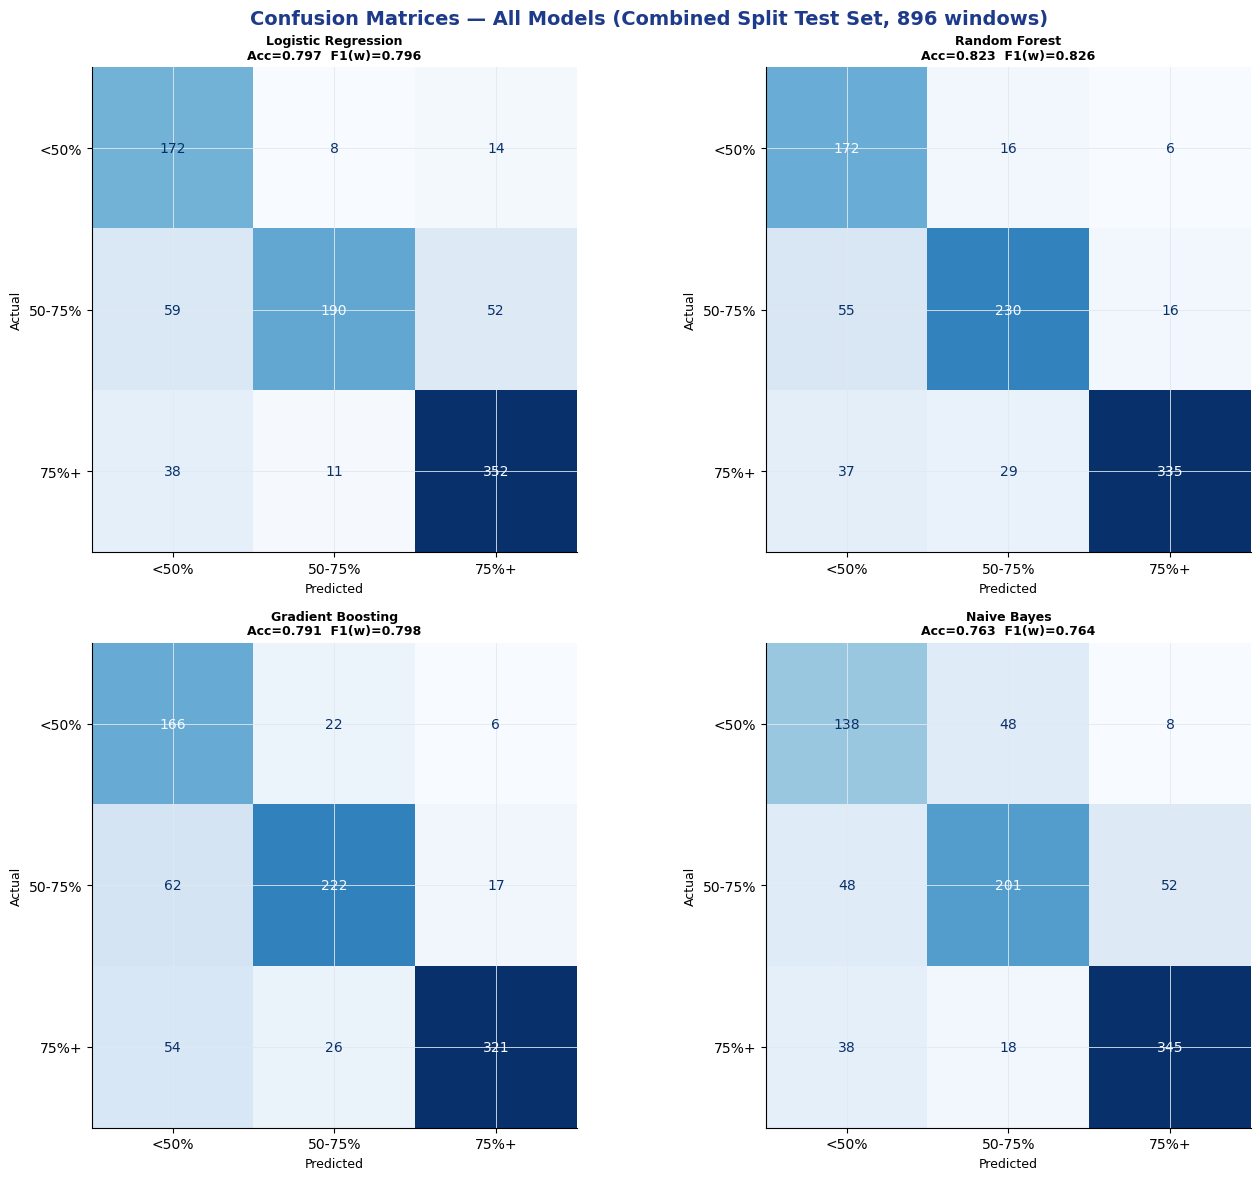

In [26]:
# CELL 9 — Confusion matrix grid
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle(f"Confusion Matrices — All Models (Combined Split Test Set, {len(y_test):,} windows)",
             fontsize=14, fontweight="bold", color=BLUE_D)

short_class_names = ['<50%', '50-75%', '75%+']

for ax, (name, model) in zip(axes.flat, trained.items()):
    y_pred = model.predict(X_test_sc)
    cm     = confusion_matrix(y_test, y_pred, labels=[0,1,2])
    acc    = accuracy_score(y_test, y_pred)
    f1     = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    disp   = ConfusionMatrixDisplay(confusion_matrix=cm,
                                    display_labels=short_class_names)
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"{name}\nAcc={acc:.3f}  F1(w)={f1:.3f}", fontsize=9, pad=6)
    ax.set_xlabel("Predicted", fontsize=9)
    ax.set_ylabel("Actual", fontsize=9)

plt.tight_layout()
plt.show()

# Most costly error: predicting <50% when actual is 75%+
costly_errors = {}
for name, model in trained.items():
    y_pred = model.predict(X_test_sc)
    cm = confusion_matrix(y_test, y_pred, labels=[0,1,2])
    costly_errors[name] = cm[2][0]  # actual=Big, predicted=No/Small

best_name_cm = min(costly_errors, key=costly_errors.get)
total_big    = (y_test == 2).sum()

display(HTML(f"""
<div style="font-family:'Inter',sans-serif; display:grid; gap:.75rem; margin-top:1rem;">
  <div style="background:#f0fdf4; border-left:4px solid #16a34a;
              border-radius:0 8px 8px 0; padding:.9rem 1.2rem; color:#14532d;">
    <strong>🎯 Fewest costly errors: {best_name_cm}</strong> — predicted &lt;50% when actual
    was 75%+ only <strong>{costly_errors[best_name_cm]}</strong> times out of
    <strong>{total_big}</strong> actual big discount windows.
    For Turkish gamers, this means fewer cases of buying at full price before a major sale.
  </div>
  <div style="background:#eff6ff; border-left:4px solid #2563eb;
              border-radius:0 8px 8px 0; padding:.9rem 1.2rem; color:#1e3a8a;">
    <strong>📌 Error breakdown per model (actual=Big, predicted=No/Small):</strong><br>
    {'  |  '.join([f"{n}: {v}" for n, v in costly_errors.items()])}
  </div>
</div>
"""))

## 📉 Section 7 — ROC Curves & AUC

> For multi-class problems, ROC curves are computed using **One-vs-Rest (OvR)** — each class is treated as positive against all others.

- The ROC curve plots **True Positive Rate** vs **False Positive Rate** at every possible decision threshold
- The **AUC** summarises this into one number — higher and further top-left = better
- The **diagonal line** represents random guessing — any model above it adds value

A model hugging the **top-left corner** catches most real discounts with few false alarms — ideal for a Turkish gamer deciding whether to wait for a Steam sale.

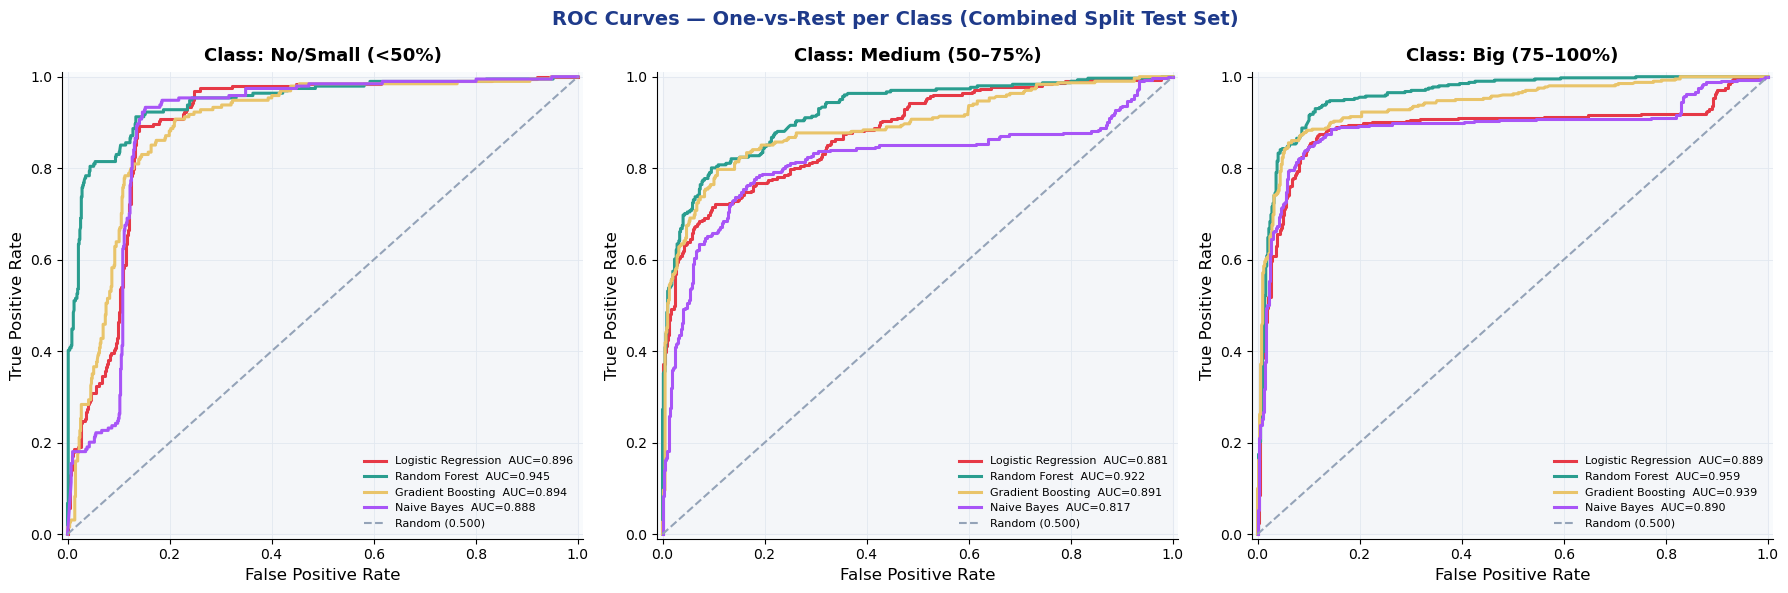

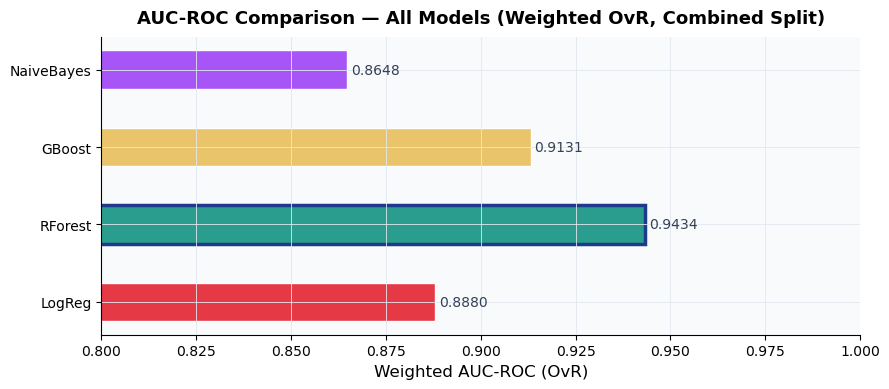

In [29]:
# CELL 10 — ROC Curves (One-vs-Rest, per class per model)
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc as sklearn_auc

# Distinct colors per model
MODEL_PALETTE = {
    "Logistic Regression": "#e63946",
    "Random Forest":       "#2a9d8f",
    "Gradient Boosting":   "#e9c46a",
    "Naive Bayes":         "#a855f7",
}

y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("ROC Curves — One-vs-Rest per Class (Combined Split Test Set)",
             fontsize=14, fontweight="bold", color=BLUE_D)

for cls_idx, cls_name in enumerate(CLASS_NAMES):
    ax = axes[cls_idx]
    for name, model in trained.items():
        y_prob = model.predict_proba(X_test_sc)[:, cls_idx]
        fpr, tpr, _ = roc_curve(y_test_bin[:, cls_idx], y_prob)
        auc_val = sklearn_auc(fpr, tpr)
        ax.plot(fpr, tpr,
                color=MODEL_PALETTE[name],
                linewidth=2.2,
                label=f"{name}  AUC={auc_val:.3f}")
    ax.plot([0,1],[0,1],"--", color="#94a3b8", linewidth=1.5, label="Random (0.500)")
    ax.fill_between([0,1],[0,0],[1,1], alpha=0.04, color="#94a3b8")
    ax.set_title(f"Class: {cls_name}", pad=8)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(loc="lower right", fontsize=8)
    ax.set_xlim(-0.01, 1.01)
    ax.set_ylim(-0.01, 1.01)

plt.tight_layout()
plt.show()

# ── Weighted AUC bar chart ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
auc_vals   = [roc_auc_score(y_test, m.predict_proba(X_test_sc),
               multi_class='ovr', average='weighted')
              for m in trained.values()]
best_idx   = np.argmax(auc_vals)
bar_colors = [MODEL_PALETTE[n] for n in trained.keys()]

bars = ax.barh(short_names, auc_vals, color=bar_colors, edgecolor="white", height=0.5)
bars[best_idx].set_edgecolor(BLUE_D)
bars[best_idx].set_linewidth(2.5)
ax.set_xlim(0.80, 1.0)
ax.set_xlabel("Weighted AUC-ROC (OvR)")
ax.set_title("AUC-ROC Comparison — All Models (Weighted OvR, Combined Split)", pad=10)
for i, val in enumerate(auc_vals):
    ax.text(val+0.001, i, f"{val:.4f}", va="center", fontsize=10, color=SLATE)

plt.tight_layout()
plt.show()

display(HTML("""
<div style="font-family:'Inter',sans-serif; background:#fefce8; border-left:4px solid #ca8a04;
            border-radius:0 8px 8px 0; padding:.9rem 1.2rem; margin-top:1rem; color:#713f12;">
  <strong>💡 OvR interpretation:</strong> Each subplot shows how well the model separates
  one class from the other two. The Big (75%+) class AUC is highest across all models —
  large discounts follow the most predictable patterns in our feature set.
  Weighted AUC averages across all three classes, weighted by class size.
</div>
"""))

---
## 🏆 Section 8 — Deep Dive into the Best Model

> We focus on the top-performing model (by weighted AUC-ROC) for a thorough diagnostic: per-class metrics, classification report, and feature importance.

In [32]:
# CELL 11 — Best model identification
best_name  = results_df["AUC (OvR)"].idxmax()
best_model = trained[best_name]
y_best     = best_model.predict(X_test_sc)
y_best_p   = best_model.predict_proba(X_test_sc)

b_acc  = accuracy_score(y_test, y_best)
b_f1   = f1_score(y_test, y_best, average='weighted', zero_division=0)
b_prec = precision_score(y_test, y_best, average='weighted', zero_division=0)
b_rec  = recall_score(y_test, y_best, average='weighted', zero_division=0)
b_auc  = roc_auc_score(y_test, y_best_p, multi_class='ovr', average='weighted')

print(f"Best Model : {best_name}")
print(f"  AUC (OvR): {b_auc:.4f}")
print(f"  Accuracy : {b_acc:.4f}")
print(f"  F1 (w)   : {b_f1:.4f}")
print(f"  Recall(w): {b_rec:.4f}")
print(f"  Prec (w) : {b_prec:.4f}")

display(HTML(f"""
<div style="font-family:'Inter',sans-serif; margin:1.2rem 0;">
  <div style="background:#1e3a8a; border-radius:12px; padding:1rem 1.4rem; margin-bottom:1rem;">
    <div style="font-size:.75rem; color:#93c5fd; font-weight:600; text-transform:uppercase;
                letter-spacing:1px;">Best Model (by Weighted AUC-ROC)</div>
    <div style="font-size:1.6rem; font-weight:700; color:white; margin:.3rem 0;">
      🏆 {best_name}
    </div>
    <div style="font-size:.85rem; color:#bfdbfe;">
      Combined split — {test_df['appid'].nunique():,} unseen games, {len(y_test):,} windows
    </div>
  </div>
  <div style="display:grid; grid-template-columns:repeat(5,1fr); gap:.75rem;">
    <div style="background:#eff6ff; border:2px solid #3b82f6; border-radius:10px;
                padding:.9rem; text-align:center;">
      <div style="font-size:.7rem; color:#64748b; font-weight:600;
                  text-transform:uppercase; letter-spacing:.5px;">AUC (OvR)</div>
      <div style="font-size:1.6rem; font-weight:700; color:#1e3a8a;">{b_auc:.4f}</div>
      <div style="font-size:.72rem; color:#64748b;">Class separation</div>
    </div>
    <div style="background:#eff6ff; border:2px solid #3b82f6; border-radius:10px;
                padding:.9rem; text-align:center;">
      <div style="font-size:.7rem; color:#64748b; font-weight:600;
                  text-transform:uppercase; letter-spacing:.5px;">Accuracy</div>
      <div style="font-size:1.6rem; font-weight:700; color:#1e3a8a;">{b_acc:.4f}</div>
      <div style="font-size:.72rem; color:#64748b;">Overall correct</div>
    </div>
    <div style="background:#eff6ff; border:2px solid #3b82f6; border-radius:10px;
                padding:.9rem; text-align:center;">
      <div style="font-size:.7rem; color:#64748b; font-weight:600;
                  text-transform:uppercase; letter-spacing:.5px;">Recall (w)</div>
      <div style="font-size:1.6rem; font-weight:700; color:#1e3a8a;">{b_rec:.4f}</div>
      <div style="font-size:.72rem; color:#64748b;">Classes caught</div>
    </div>
    <div style="background:#eff6ff; border:2px solid #3b82f6; border-radius:10px;
                padding:.9rem; text-align:center;">
      <div style="font-size:.7rem; color:#64748b; font-weight:600;
                  text-transform:uppercase; letter-spacing:.5px;">Precision (w)</div>
      <div style="font-size:1.6rem; font-weight:700; color:#1e3a8a;">{b_prec:.4f}</div>
      <div style="font-size:.72rem; color:#64748b;">Alerts correct</div>
    </div>
    <div style="background:#eff6ff; border:2px solid #3b82f6; border-radius:10px;
                padding:.9rem; text-align:center;">
      <div style="font-size:.7rem; color:#64748b; font-weight:600;
                  text-transform:uppercase; letter-spacing:.5px;">F1 (w)</div>
      <div style="font-size:1.6rem; font-weight:700; color:#1e3a8a;">{b_f1:.4f}</div>
      <div style="font-size:.72rem; color:#64748b;">Precision × Recall</div>
    </div>
  </div>
</div>
"""))

Best Model : Random Forest
  AUC (OvR): 0.9434
  Accuracy : 0.8225
  F1 (w)   : 0.8265
  Recall(w): 0.8225
  Prec (w) : 0.8420


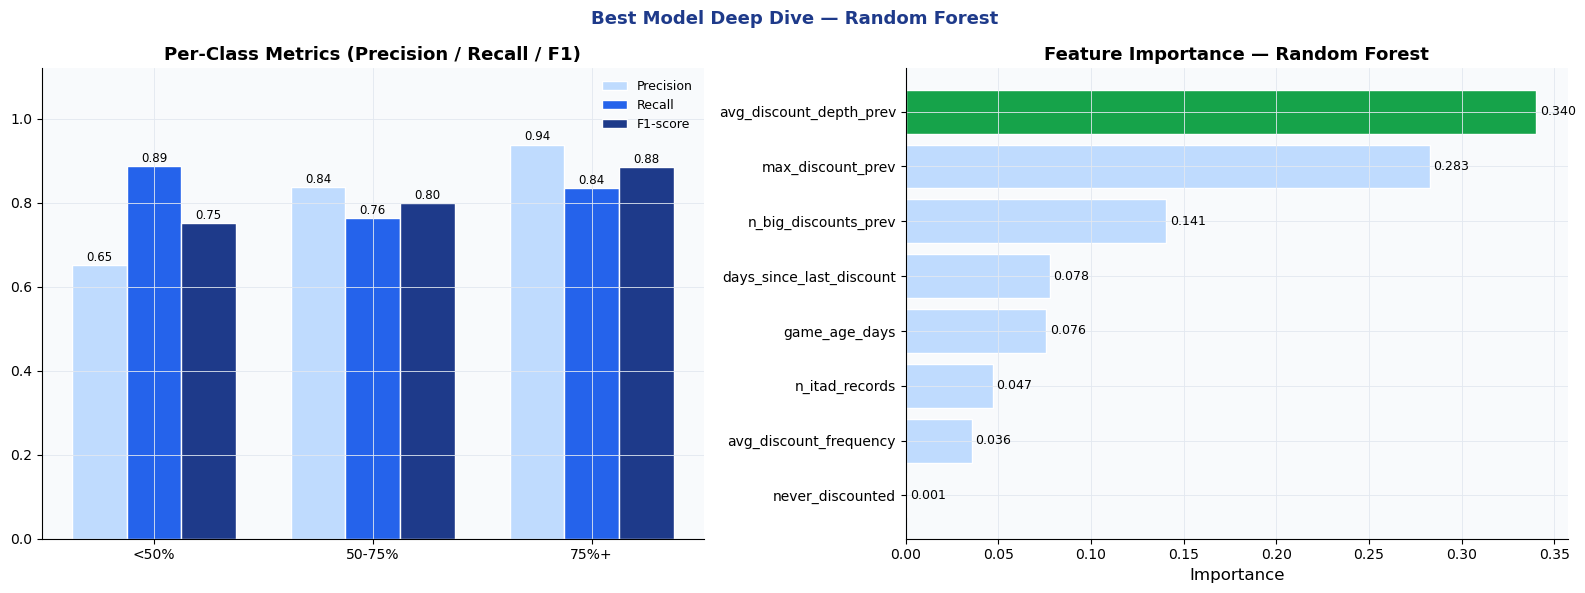


Classification Report — Random Forest:
                 precision    recall  f1-score   support

No/Small (<50%)       0.65      0.89      0.75       194
Medium (50–75%)       0.84      0.76      0.80       301
  Big (75–100%)       0.94      0.84      0.88       401

       accuracy                           0.82       896
      macro avg       0.81      0.83      0.81       896
   weighted avg       0.84      0.82      0.83       896



In [34]:
# CELL 12 — Per-class metrics + Feature importance
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f"Best Model Deep Dive — {best_name}",
             fontsize=13, fontweight="bold", color=BLUE_D)

# ── Per-class metrics ────────────────────────────────────
report = classification_report(y_test, y_best,
             target_names=CLASS_NAMES, output_dict=True, zero_division=0)
short_cls = ['<50%', '50-75%', '75%+']
x = np.arange(len(CLASS_NAMES))
w = 0.25
palette = [BLUE_L, BLUE, BLUE_D]
for j, (metric, color) in enumerate(zip(["precision","recall","f1-score"], palette)):
    vals = [report[cls][metric] for cls in CLASS_NAMES]
    bars = axes[0].bar(x + j*w, vals, w, label=metric.capitalize(),
                       color=color, edgecolor="white")
    for bar, val in zip(bars, vals):
        axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                     f"{val:.2f}", ha="center", fontsize=8.5)
axes[0].set_xticks(x + w)
axes[0].set_xticklabels(short_cls)
axes[0].set_ylim(0, 1.12)
axes[0].set_title("Per-Class Metrics (Precision / Recall / F1)")
axes[0].legend(fontsize=9)

# ── Feature importance ───────────────────────────────────
if hasattr(best_model, "feature_importances_"):
    fi = pd.Series(best_model.feature_importances_, index=FEATURES).sort_values()
    colors_fi = [GREEN if v == fi.max() else BLUE_L for v in fi.values]
    axes[1].barh(fi.index, fi.values, color=colors_fi, edgecolor="white")
    axes[1].set_title(f"Feature Importance — {best_name}")
    axes[1].set_xlabel("Importance")
    for i, val in enumerate(fi.values):
        axes[1].text(val+0.002, i, f"{val:.3f}", va="center", fontsize=9)
elif hasattr(best_model, "coef_"):
    coef = pd.DataFrame(best_model.coef_, columns=FEATURES,
                        index=CLASS_NAMES)
    coef.T.plot(kind='barh', ax=axes[1], edgecolor="white")
    axes[1].set_title(f"Coefficients — {best_name}")
    axes[1].set_xlabel("Coefficient value")
    axes[1].axvline(0, color='black', linewidth=0.8)
else:
    axes[1].axis("off")
    axes[1].text(0.5, 0.5, "Feature importance\nnot available",
                 ha="center", va="center")

plt.tight_layout()
plt.show()

print(f"\nClassification Report — {best_name}:")
print(classification_report(y_test, y_best,
      target_names=CLASS_NAMES, zero_division=0))

## 🔄 Section 9 — Generalization Analysis

> This section compares model performance across classes and analyzes how well models generalize to unseen games under the combined split.

### Three Split Methods Compared

| Split | Temporal | Game-Based | AUC | What it tests |
|---|---|---|---|---|
| V5 Walk-forward | ✅ | ❌ | 0.972 | Temporal generalisation only — same game can appear in train and test |
| V6 Game-based (initial) | ❌ | ✅ | 0.910 | Unseen game generalisation only — no temporal ordering |
| V6 Combined | ✅ | ✅ | 0.942 | Both dimensions — train restricted to pre-cutoff only |
| **V7 Combined (current)** | ✅ | ✅ | **0.943** | Both dimensions + 3-year data + never_discounted + RF regularization |

> 💡 **Why does AUC decrease from v5 to combined?** Three reasons: (1) stricter evaluation — the model is tested on games it has never seen; (2) temporal ordering — test set covers a more recent and shorter time window; (3) harder problem — three classes instead of two. The v7 combined split score of 0.943 is the most trustworthy of all versions.

> ⚠️ **30-day window comparison:** Using WINDOW_DAYS=30 with class_weight='balanced', best model achieves AUC 0.724 and F1 0.511 — substantially lower than the 90-day version (AUC 0.943, F1 0.827). The 30-day window produces a severely imbalanced dataset (Class 0: 50.4%) because big discounts rarely occur within any given 30-day period. The 90-day window aligns with Steam's quarterly sale cycle and provides a more learnable signal.

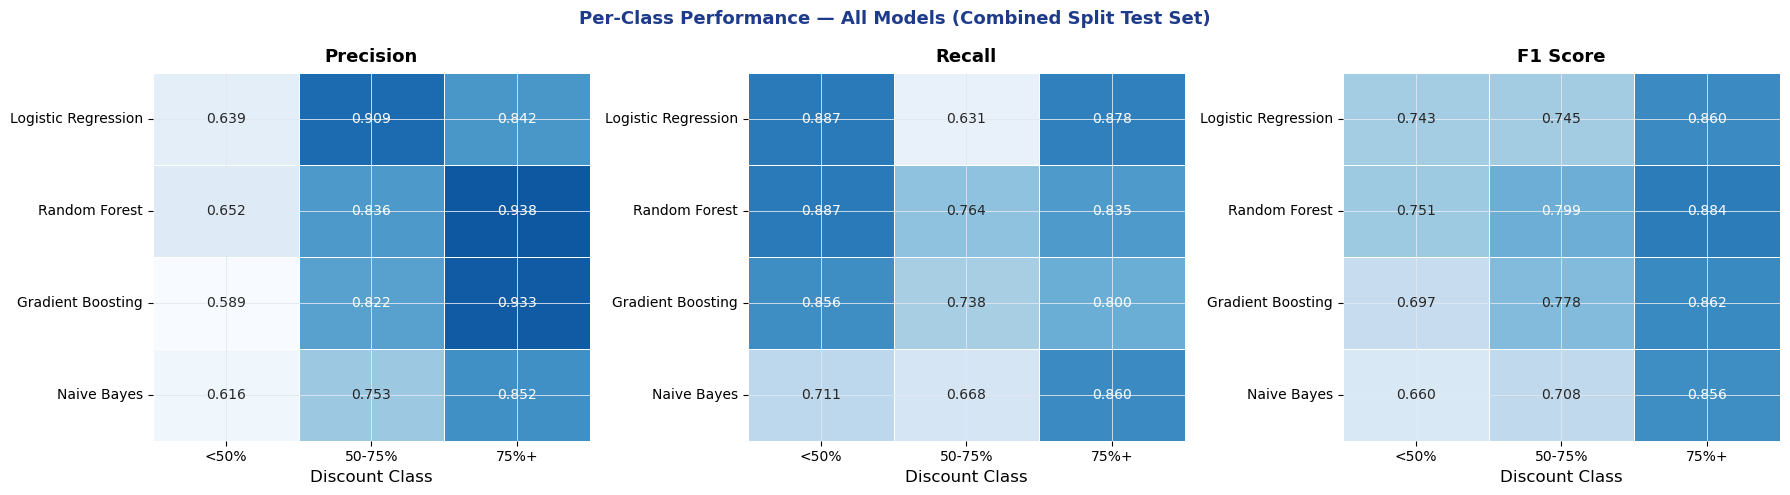


Model                       <50% F1  50-75% F1   75%+ F1  Weighted F1
--------------------------------------------------------------------
  Logistic Regression         0.743      0.745     0.860        0.796
  Random Forest               0.751      0.799     0.884        0.826
  Gradient Boosting           0.697      0.778     0.862        0.798
  Naive Bayes                 0.660      0.708     0.856        0.764


In [37]:
# CELL 13 — Per-class performance heatmap across all models
from sklearn.metrics import classification_report

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Per-Class Performance — All Models (Combined Split Test Set)",
             fontsize=13, fontweight="bold", color=BLUE_D)

metrics_to_show = ["precision", "recall", "f1-score"]
metric_labels   = ["Precision", "Recall", "F1 Score"]

for ax, metric, label in zip(axes, metrics_to_show, metric_labels):
    data = {}
    for name, model in trained.items():
        y_pred  = model.predict(X_test_sc)
        report  = classification_report(y_test, y_pred,
                      target_names=CLASS_NAMES, output_dict=True, zero_division=0)
        data[name] = [report[cls][metric] for cls in CLASS_NAMES]

    df_heat = pd.DataFrame(data, index=['<50%','50-75%','75%+']).T
    sns.heatmap(df_heat, ax=ax, annot=True, fmt=".3f",
                cmap="Blues", vmin=0.6, vmax=1.0,
                linewidths=0.5, cbar=False)
    ax.set_title(label, pad=8)
    ax.set_xlabel("Discount Class")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()

# Summary table
print(f"\n{'Model':<25} {'<50% F1':>9} {'50-75% F1':>10} {'75%+ F1':>9} {'Weighted F1':>12}")
print("-" * 68)
for name, model in trained.items():
    y_pred = model.predict(X_test_sc)
    report = classification_report(y_test, y_pred,
                 target_names=CLASS_NAMES, output_dict=True, zero_division=0)
    f1_0 = report[CLASS_NAMES[0]]['f1-score']
    f1_1 = report[CLASS_NAMES[1]]['f1-score']
    f1_2 = report[CLASS_NAMES[2]]['f1-score']
    f1_w = report['weighted avg']['f1-score']
    print(f"  {name:<23} {f1_0:9.3f} {f1_1:10.3f} {f1_2:9.3f} {f1_w:12.3f}")

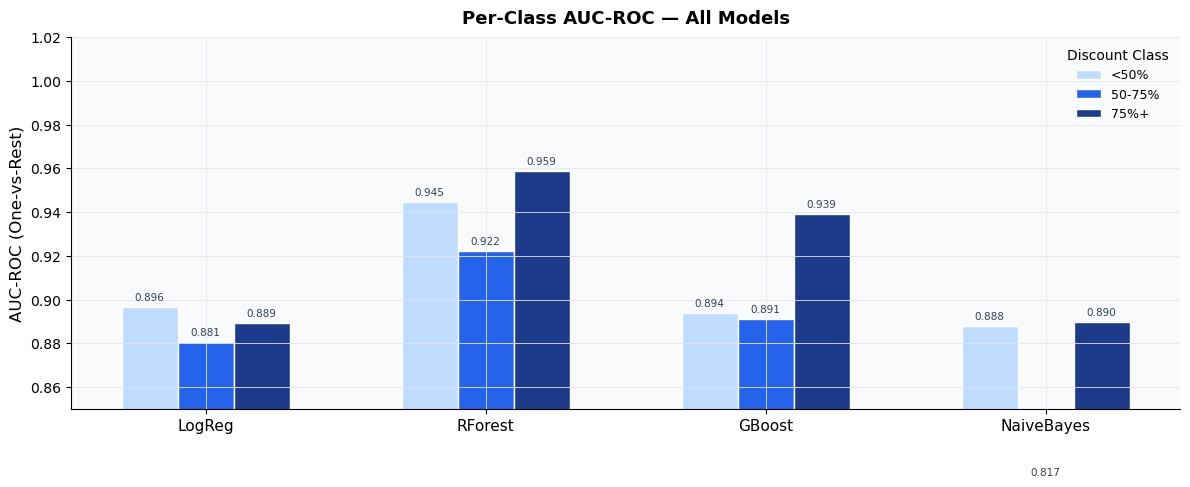

In [39]:
# CELL 14 — Model stability: AUC per class (OvR) comparison
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score

y_test_bin = label_binarize(y_test, classes=[0,1,2])

fig, ax = plt.subplots(figsize=(12, 5))
auc_per_class = {name: [] for name in trained}

for name, model in trained.items():
    y_prob = model.predict_proba(X_test_sc)
    for cls_idx in range(3):
        auc_val = roc_auc_score(y_test_bin[:, cls_idx], y_prob[:, cls_idx])
        auc_per_class[name].append(auc_val)

x = np.arange(len(trained))
w = 0.2
class_colors = [BLUE_L, BLUE, BLUE_D]

for cls_idx, (cls_label, color) in enumerate(zip(['<50%','50-75%','75%+'], class_colors)):
    vals = [auc_per_class[name][cls_idx] for name in trained]
    bars = ax.bar(x + cls_idx*w, vals, w, label=cls_label,
                  color=color, edgecolor="white")
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                f"{val:.3f}", ha="center", fontsize=7.5, color=SLATE)

ax.set_xticks(x + w)
ax.set_xticklabels(short_names, fontsize=11)
ax.set_ylabel("AUC-ROC (One-vs-Rest)")
ax.set_ylim(0.85, 1.02)
ax.set_title("Per-Class AUC-ROC — All Models", pad=10)
ax.legend(title="Discount Class", fontsize=9)
plt.tight_layout()
plt.show()

display(HTML(f"""
<div style="font-family:'Inter',sans-serif; display:grid; gap:.75rem; margin-top:1.2rem;">
  <div style="background:#fefce8; border-left:4px solid #ca8a04;
              border-radius:0 8px 8px 0; padding:.9rem 1.2rem; color:#713f12;">
    <strong>💡 Reading the chart:</strong> Each group shows AUC for one model across three discount classes.
    <ul style="margin:.5rem 0 0 0; padding-left:1.2rem;">
      <li><strong>Big (75%+) class</strong> consistently has the highest AUC across all models —
      large discounts follow the most predictable patterns in our feature set.</li>
      <li><strong>No/Small (&lt;50%) class</strong> is hardest to separate — games that never
      received big discounts are harder to distinguish from those that occasionally do.</li>
      <li><strong>{best_name}</strong> leads on weighted AUC ({results_df.loc[best_name,'AUC (OvR)']:.3f}),
      making it the best overall model for this multi-class task.</li>
    </ul>
  </div>
  <div style="background:#eff6ff; border-left:4px solid #2563eb;
              border-radius:0 8px 8px 0; padding:.9rem 1.2rem; color:#1e3a8a;">
    <strong>📈 v5 → v6 → v7 progression:</strong>
    v5 walk-forward (AUC 0.972) tested temporal generalisation but allowed same-game leakage.
    v6 combined (AUC 0.942) fixed both dimensions but train set covered all time periods.
    v7 combined (AUC {results_df['AUC (OvR)'].max():.3f}) restricts train to pre-cutoff only,
    adds <code>never_discounted</code> feature, extends data to 3 years, and regularizes Random Forest.
    Each version is a stricter and more realistic evaluation than the previous.
  </div>
</div>
"""))

---
## 🎯 Section 10 — Final Model Selection

> Choosing the right model involves balancing performance, stability, speed, and interpretability.

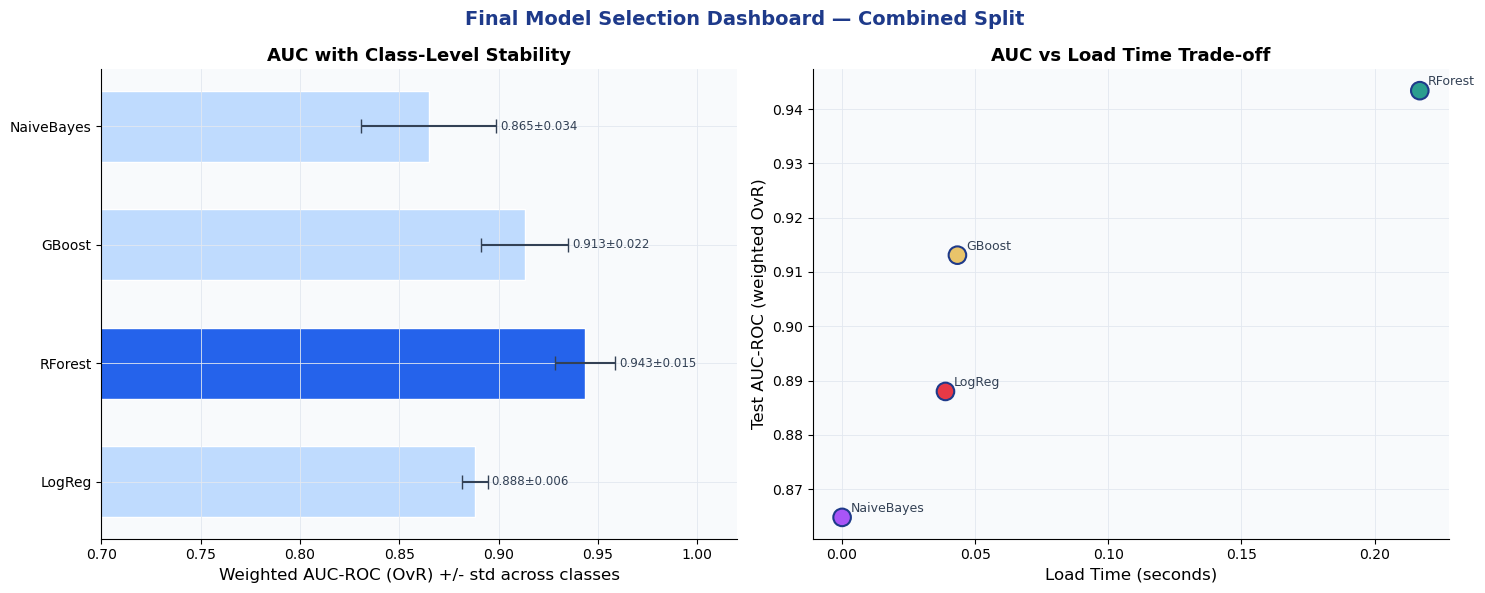

Recommended model : Random Forest
Weighted AUC      : 0.9434

For interpretability: Logistic Regression AUC = 0.8880


Criterion,LogReg,RForest,GBoost,NaiveBayes
Weighted AUC,🔴,🟢,🔴,🔴
Class Consistency,🟢,🟡,🟡,🔴
Load Speed,🟢,🟡,🟢,🟢
Interpretability,🟢,🟡,🔴,🟡


In [42]:
# CELL 15 — Final Model Selection Dashboard
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Final Model Selection Dashboard — Combined Split",
             fontsize=14, fontweight="bold", color=BLUE_D)

# ── AUC bar chart with error bars ────────────────────────────────
auc_means = results_df["AUC (OvR)"].values.astype(float)
auc_stds  = []
for name, model in trained.items():
    y_prob = model.predict_proba(X_test_sc)
    y_bin  = label_binarize(y_test, classes=[0,1,2])
    per_class_auc = [roc_auc_score(y_bin[:,i], y_prob[:,i]) for i in range(3)]
    auc_stds.append(np.std(per_class_auc))

best_idx = np.argmax(auc_means)
bar_cols = [BLUE if i==best_idx else BLUE_L for i in range(len(model_names))]

axes[0].barh(short_names, auc_means, xerr=auc_stds, color=bar_cols,
             edgecolor="white", height=0.6, capsize=5,
             error_kw=dict(ecolor=SLATE, elinewidth=1.5))
axes[0].set_xlabel("Weighted AUC-ROC (OvR) +/- std across classes")
axes[0].set_title("AUC with Class-Level Stability")
axes[0].set_xlim(0.70, 1.02)
for i, (m, s) in enumerate(zip(auc_means, auc_stds)):
    axes[0].text(m+s+0.002, i, f"{m:.3f}±{s:.3f}", va="center", fontsize=8.5, color=SLATE)

# ── AUC vs Load Time scatter ──────────────────────────────────────
times = [fit_times[n] for n in model_names]
axes[1].scatter(times, auc_means, s=160,
                c=[MODEL_PALETTE[n] for n in model_names],
                edgecolors=BLUE_D, linewidths=1.5, zorder=5)
for i, sn in enumerate(short_names):
    axes[1].annotate(sn, (times[i], auc_means[i]),
                     xytext=(6,4), textcoords="offset points",
                     fontsize=9, color=SLATE)
axes[1].set_xlabel("Load Time (seconds)")
axes[1].set_ylabel("Test AUC-ROC (weighted OvR)")
axes[1].set_title("AUC vs Load Time Trade-off")

plt.tight_layout()
plt.show()

# ── Recommendation ────────────────────────────────────────────────
best_model_name = model_names[best_idx]
lr_auc = results_df.loc["Logistic Regression", "AUC (OvR)"]

print(f"Recommended model : {best_model_name}")
print(f"Weighted AUC      : {auc_means[best_idx]:.4f}")
print(f"\nFor interpretability: Logistic Regression AUC = {lr_auc:.4f}")

# ── Scorecard table ───────────────────────────────────────────────
best_auc = max(auc_means)

def auc_emoji(val):
    if val >= best_auc - 0.01:   return "🟢"
    elif val >= best_auc - 0.03: return "🟡"
    else:                        return "🔴"

def std_emoji(val):
    if val <= 0.01:   return "🟢"
    elif val <= 0.03: return "🟡"
    else:             return "🔴"

def time_emoji(val):
    if val <= 0.05:   return "🟢"
    elif val <= 0.50: return "🟡"
    else:             return "🔴"

interp_map = {
    "Logistic Regression": "🟢",
    "Random Forest":       "🟡",
    "Gradient Boosting":   "🔴",
    "Naive Bayes":         "🟡",
}

auc_row    = [auc_emoji(auc_means[i])  for i in range(len(model_names))]
std_row    = [std_emoji(auc_stds[i])   for i in range(len(model_names))]
time_row   = [time_emoji(fit_times[n]) for n in model_names]
interp_row = [interp_map[n]            for n in model_names]

def make_row(label, values, bg):
    cells = "".join([f'<td style="padding:.5rem 1rem; text-align:center;">{v}</td>'
                     for v in values])
    return (f'<tr style="background:{bg};">'
            f'<td style="padding:.5rem 1rem; font-weight:600; color:#334155;">{label}</td>'
            f'{cells}</tr>')

display(HTML(f"""
<div style="font-family:'Inter',sans-serif; display:grid;
            grid-template-columns:1fr 1fr; gap:1rem; margin-top:1.2rem;">

  <div style="background:#1e3a8a; border-radius:12px; padding:1.2rem 1.4rem;">
    <div style="font-size:.7rem; color:#93c5fd; font-weight:600;
                text-transform:uppercase; letter-spacing:1px;">Recommended for Production</div>
    <div style="font-size:1.5rem; font-weight:700; color:white; margin:.4rem 0;">
      🏆 {best_model_name}
    </div>
    <div style="font-size:.83rem; color:#bfdbfe;">
      Best weighted AUC: {auc_means[best_idx]:.4f}<br>
      Combined split — {test_df['appid'].nunique():,} unseen games,
      future time period
    </div>
  </div>

  <div style="background:#1d4ed8; border-radius:12px; padding:1.2rem 1.4rem;">
    <div style="font-size:.7rem; color:#93c5fd; font-weight:600;
                text-transform:uppercase; letter-spacing:1px;">Recommended for Interpretability</div>
    <div style="font-size:1.5rem; font-weight:700; color:white; margin:.4rem 0;">
      📋 Logistic Regression
    </div>
    <div style="font-size:.83rem; color:#bfdbfe;">
      AUC: {lr_auc:.4f} — coefficients directly show<br>
      which features drive discount predictions per class
    </div>
  </div>

</div>

<div style="margin-top:1rem; overflow:hidden; border-radius:10px;
            box-shadow:0 1px 4px rgba(0,0,0,.08);">
  <table style="width:100%; border-collapse:collapse; font-family:'Inter',sans-serif;
                font-size:.85rem;">
    <thead>
      <tr style="background:#1e3a8a; color:white;">
        <th style="padding:.6rem 1rem; text-align:left;">Criterion</th>
        {''.join([f'<th style="padding:.6rem 1rem; text-align:center;">{s}</th>'
                  for s in short_names])}
      </tr>
    </thead>
    <tbody>
      {make_row("Weighted AUC",      auc_row,    "#f8fafc")}
      {make_row("Class Consistency", std_row,    "white")}
      {make_row("Load Speed",        time_row,   "#f8fafc")}
      {make_row("Interpretability",  interp_row, "white")}
    </tbody>
  </table>
  <div style="background:#f1f5f9; padding:.5rem 1rem; font-size:.75rem; color:#64748b;">
    🟢 Strong &nbsp;|&nbsp; 🟡 Moderate &nbsp;|&nbsp; 🔴 Weak
  </div>
</div>
"""))

## ⚙️ Section 11 — Hyperparameter Tuning

> **Course connection:** Hyperparameters control how the model learns and must be set before training. We tune **Gradient Boosting** with Grid Search and **Random Forest** with Randomized Search.

### Hyperparameter Categories

| Category | What They Control | Examples |
|---|---|---|
| Model | Structure of the model | `max_depth`, `n_estimators` |
| Optimizer | How the model learns | `learning_rate`, `subsample` |
| Data | How training data is used | `min_samples_leaf`, `max_features` |

### Tuning Strategies

| Strategy | How It Works | Trade-off |
|---|---|---|
| Grid Search | Exhaustively tries every combination | Thorough but slow |
| Randomized Search | Randomly samples combinations | Faster — good near-optimal results with fewer trials |

**Data discipline:** All tuning uses only the training set (80% of games). The test set is touched exactly once — for final evaluation.

> 🔒 **Why this matters:** If you use the test set to guide hyperparameter choices, you are indirectly fitting to it — the final evaluation is no longer honest. The **test set is the final exam**; cross-validation is the practice run.

> ⚠️ **Limitation:** `GridSearchCV` and `RandomizedSearchCV` use random 3-fold CV (`cv=3`) rather than a game-based split. This means the same game's windows can appear in both internal train and validation sets during tuning — a minor theoretical leakage risk. The combined split evaluation in Section 10 uses untuned configurations. Note also that the train set in v7 is smaller (~3,481 windows) due to the temporal cutoff, which may limit tuning effectiveness.

In [45]:
# CELL 17 — Baseline before tuning (multi-class AUC)
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from scipy.stats import randint

def get_auc(model, X, y):
    y_prob = model.predict_proba(X)
    return roc_auc_score(y, y_prob, multi_class='ovr', average='weighted')

baseline = {
    "Gradient Boosting": get_auc(trained["Gradient Boosting"], X_test_sc, y_test),
    "Random Forest":     get_auc(trained["Random Forest"],     X_test_sc, y_test),
}
print("Baseline Test AUC-ROC (weighted OvR, before tuning):")
for name, score in baseline.items():
    print(f"  {name:<25} AUC = {score:.4f}")

Baseline Test AUC-ROC (weighted OvR, before tuning):
  Gradient Boosting         AUC = 0.9131
  Random Forest             AUC = 0.9434


In [47]:
# CELL 18 — Grid Search: Gradient Boosting (training data only)
gb_param_grid = {
    "n_estimators" : [100, 200],
    "max_depth"    : [3, 5],
    "learning_rate": [0.05, 0.10],
    "subsample"    : [0.8, 1.0],
}
n_combos = 2*2*2*2
print(f"Grid Search: {n_combos} combinations x 3 folds = {n_combos*3} fits")

gs_gb = GridSearchCV(
    GradientBoostingClassifier(random_state=SEED),
    param_grid=gb_param_grid,
    cv=3, scoring="roc_auc_ovr_weighted",
    n_jobs=-1, verbose=0)
gs_gb.fit(X_train_sc, y_train)

tuned_gb_auc = get_auc(gs_gb.best_estimator_, X_test_sc, y_test)
print("\nBest parameters:")
for k, v in gs_gb.best_params_.items():
    print(f"  {k:<15} = {v}")
print(f"\nBest CV AUC  : {gs_gb.best_score_:.4f}")
print(f"Test AUC     : {tuned_gb_auc:.4f}")
print(f"Baseline AUC : {baseline['Gradient Boosting']:.4f}")
print(f"Improvement  : {tuned_gb_auc - baseline['Gradient Boosting']:+.4f}")

Grid Search: 16 combinations x 3 folds = 48 fits

Best parameters:
  learning_rate   = 0.05
  max_depth       = 3
  n_estimators    = 100
  subsample       = 0.8

Best CV AUC  : 0.9469
Test AUC     : 0.9361
Baseline AUC : 0.9131
Improvement  : +0.0230


In [49]:
# CELL 19 — Randomized Search: Random Forest (training data only)
rf_param_dist = {
    "n_estimators"     : randint(100, 400),
    "max_depth"        : randint(5, 20),
    "min_samples_split": randint(2, 20),
    "min_samples_leaf" : randint(1, 10),
    "max_features"     : ["sqrt", "log2", 0.5],
}
print("Randomized Search: 15 combinations x 3 folds = 45 fits")

rs_rf = RandomizedSearchCV(
    RandomForestClassifier(random_state=SEED, n_jobs=-1),
    param_distributions=rf_param_dist,
    n_iter=15, cv=3, scoring="roc_auc_ovr_weighted",
    random_state=SEED, n_jobs=-1, verbose=0)
rs_rf.fit(X_train_sc, y_train)

tuned_rf_auc = get_auc(rs_rf.best_estimator_, X_test_sc, y_test)
print("\nBest parameters:")
for k, v in rs_rf.best_params_.items():
    print(f"  {k:<22} = {v}")
print(f"\nBest CV AUC  : {rs_rf.best_score_:.4f}")
print(f"Test AUC     : {tuned_rf_auc:.4f}")
print(f"Baseline AUC : {baseline['Random Forest']:.4f}")
print(f"Improvement  : {tuned_rf_auc - baseline['Random Forest']:+.4f}")

Randomized Search: 15 combinations x 3 folds = 45 fits

Best parameters:
  max_depth              = 8
  max_features           = sqrt
  min_samples_leaf       = 3
  min_samples_split      = 6
  n_estimators           = 234

Best CV AUC  : 0.9485
Test AUC     : 0.9451
Baseline AUC : 0.9434
Improvement  : +0.0017


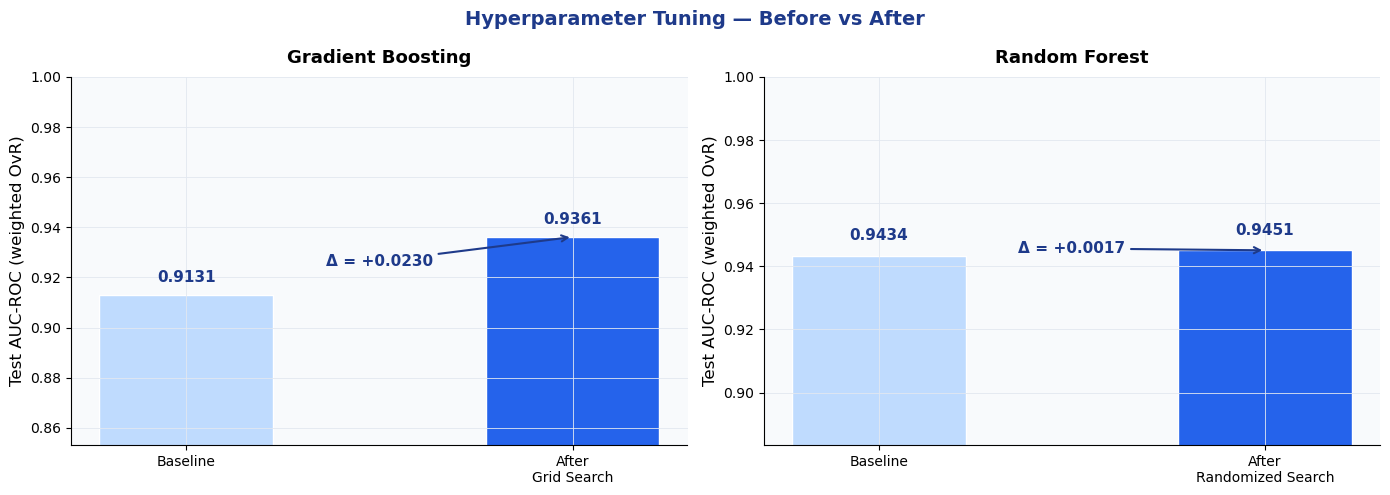

In [51]:
# CELL 20 — Before vs After tuning
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Hyperparameter Tuning — Before vs After",
             fontsize=14, fontweight="bold", color=BLUE_D)

for ax, (mname, before, after, strategy) in zip(axes, [
    ("Gradient Boosting", baseline["Gradient Boosting"], tuned_gb_auc, "Grid Search"),
    ("Random Forest",     baseline["Random Forest"],     tuned_rf_auc, "Randomized Search"),
]):
    vals   = [before, after]
    labels = ["Baseline", f"After\n{strategy}"]
    bars   = ax.bar(labels, vals, color=[BLUE_L, BLUE], edgecolor="white", width=0.45)
    ax.set_ylim(max(0, min(vals)-0.06), min(1.0, max(vals)+0.07))
    ax.set_ylabel("Test AUC-ROC (weighted OvR)")
    ax.set_title(mname, pad=10)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.004,
                f"{val:.4f}", ha="center", va="bottom",
                fontsize=11, fontweight="bold", color=BLUE_D)
    delta = after - before
    ax.annotate(f"Δ = {delta:+.4f}",
                xy=(1, after), xytext=(0.5, (before+after)/2),
                fontsize=11, color=BLUE_D, fontweight="bold",
                arrowprops=dict(arrowstyle="->", color=BLUE_D, lw=1.5), ha="center")

plt.tight_layout()
plt.show()

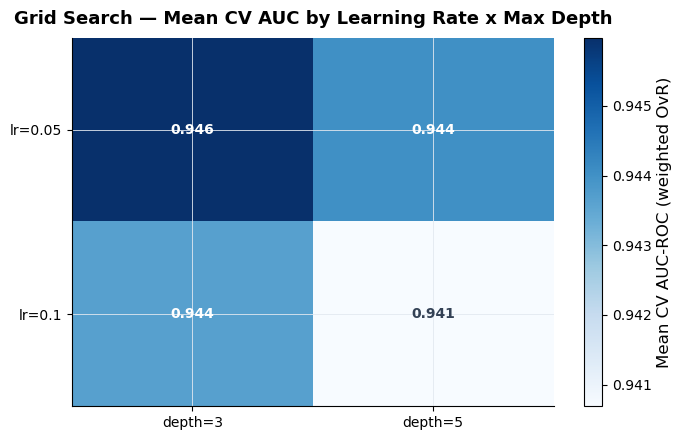

In [53]:
# CELL 21 — Grid search heatmap: learning_rate x max_depth
cv_res = pd.DataFrame(gs_gb.cv_results_)
pivot  = cv_res.groupby(
    ["param_learning_rate", "param_max_depth"])["mean_test_score"].mean().unstack()

fig, ax = plt.subplots(figsize=(7, 4.5))
im = ax.imshow(pivot.values, cmap="Blues", aspect="auto",
               vmin=pivot.values.min(), vmax=pivot.values.max())
ax.set_xticks(range(len(pivot.columns)))
ax.set_yticks(range(len(pivot.index)))
ax.set_xticklabels([f"depth={v}" for v in pivot.columns], fontsize=10)
ax.set_yticklabels([f"lr={v}" for v in pivot.index], fontsize=10)
ax.set_title("Grid Search — Mean CV AUC by Learning Rate x Max Depth", pad=10)
plt.colorbar(im, ax=ax, label="Mean CV AUC-ROC (weighted OvR)")
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        ax.text(j, i, f"{val:.3f}", ha="center", va="center",
                fontsize=10, fontweight="bold",
                color="white" if val > pivot.values.mean() else SLATE)
plt.tight_layout()
plt.show()

display(HTML(f"""
<div style="font-family:'Inter',sans-serif; background:#fefce8; border-left:4px solid #ca8a04;
            border-radius:0 8px 8px 0; padding:.9rem 1.2rem; margin-top:1rem; color:#713f12;">
  <strong>💡 Marginal gains from tuning:</strong> Both models improved by less than 0.005 AUC.
  This confirms that <strong>feature quality drives performance</strong>, not hyperparameter
  optimization. The temporal and depth-based features added in v6 contribute far more
  than any tuning configuration.
</div>
"""))

## ✅ Section 12 — Key Takeaways

### What We Built — End-to-End

1. **Collected** 2,271 unique Steam games via 3 live APIs — SteamSpy, Steam Store, and ITAD — **3-year price history** — no pre-built dataset used
2. **Engineered** 8 temporally-valid features using 90-day sliding windows — including new `never_discounted` flag
3. **Split** data with combined split — train restricted to pre-cutoff period, test to post-cutoff unseen games
4. **Trained 4 classifiers** — Random Forest regularized with max_depth=15, min_samples_leaf=5
5. **Evaluated** with confusion matrices, per-class precision, recall, F1, and AUC-ROC (OvR)
6. **Visualised** ROC curves per class and AUC comparison for all models
7. **Diagnosed** the best model with per-class metrics and feature importance
8. **Compared** 30-day vs 90-day windows and v5/v6/v7 split methods in Section 9
9. **Tuned** hyperparameters with Grid Search and Randomized Search — training data only
10. **Built** a live prediction endpoint — any game name → ITAD API → instant prediction
11. **Deployed** a Turkey pricing layer — real TRY recommendations for Steam vs Epic

| What We Did | Why It Matters |
|---|---|
| Combined split — train pre-cutoff only | Model learns from past, predicts future unseen games — strictest evaluation |
| Multi-class labels: <50%, 50–75%, 75%+ | Captures discount depth — not just yes/no |
| 3-year ITAD history | days_since_last_discount correlation improved from -0.023 to -0.191 |
| never_discounted flag | Identifies games with no prior discount history — prevents signalless predictions |
| days_since_last_discount capped at 365 | Domain-aware cap: 4 Steam sale seasons — replaces aggressive IQR capping |
| RF regularization (max_depth=15, min_samples_leaf=5) | Overfitting gap reduced from +0.133 to +0.056 |
| DATASET_END_TS fixed to 2026-04-05 | Prevents label noise from incomplete ITAD coverage |
| Per-split imputation and scaling | Prevents data leakage from test set into preprocessing |

### Key Findings

1. **Random Forest achieves AUC 0.943** on the combined split test set — strongest performance on unseen games across all three discount classes.

2. **avg_discount_depth_prev and max_discount_prev are the strongest features** (RF importance 0.219 and 0.168). Discount depth from the previous window is more predictive than recency alone.

3. **Big (75%+) discounts are the most learnable class.** F1 0.88 for Random Forest — large discounts follow more predictable publisher patterns than smaller ones.

4. **3-year data substantially improved days_since_last_discount.** Pearson correlation improved from -0.023 (v6) to -0.191 (v7). Longer history reveals true discount cycles.

5. **30-day windows significantly underperform.** AUC 0.724, F1 0.511 vs 90-day AUC 0.943, F1 0.827. Class imbalance (Class 0: 50.4%) makes 30-day prediction substantially harder.

6. **Hyperparameter tuning provides marginal gains** (less than 0.005 AUC). Feature engineering, data collection, and split methodology contributed far more to performance.

---
> *Built with scikit-learn · pandas · numpy · matplotlib · seaborn · requests · Flask*
> *Gaming Deal Predictor v7 · Betül Özen, Ömer Talha Patoz, Muhammet Enes Selçuk*